# CMS Calorimeter Super-Resolution: Conditional Diffusion Model (DiffLense-style)

## Motivation

**DiffLense** (Reddy et al., NeurIPS ML4PS 2024) applied a conditional diffusion probabilistic model to super-resolve
gravitational lensing images. The same method is directly applicable to CMS calorimeter jet images.

### How it works
A **Denoising Diffusion Probabilistic Model (DDPM)** learns to reverse a Gaussian noise process:
- **Forward process:** Gradually add noise to the HR image over T steps until it becomes pure Gaussian noise.
- **Reverse process:** A U-Net (conditioned on the LR image) learns to predict and remove noise at each step.
- At inference: start from random noise, iteratively denoise conditioned on the LR input -> get SR output.

### Why better than ESRGAN for physics data?
- Diffusion models do not suffer from GAN mode collapse.
- Iterative denoising naturally handles the complex, sparse noise profile of calorimeter data.
- The stochastic nature allows drawing multiple plausible SR samples — useful for physics uncertainty quantification.

**Reference:** DiffLense, NeurIPS ML4PS 2024 — PSNR 35.07 dB, SSIM 0.839 on 64x64->128x128 lensing data.

## 1. Imports and Device

In [1]:
import os, json, warnings, ssl, contextlib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
warnings.filterwarnings('ignore')
ssl._create_default_https_context = ssl._create_unverified_context

import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

torch.manual_seed(42); np.random.seed(42)

DEVICE = (torch.device('mps')   if torch.backends.mps.is_available() else
          torch.device('cuda')  if torch.cuda.is_available() else
          torch.device('cpu'))
USE_AMP = DEVICE.type == 'cuda'
print(f'Device: {DEVICE}  AMP: {USE_AMP}')

amp_ctx  = lambda: torch.amp.autocast('cuda') if USE_AMP else contextlib.nullcontext()
mk_scaler = lambda: torch.amp.GradScaler('cuda') if USE_AMP else None

def backward(loss, opt, scaler=None):
    if scaler: scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
    else:      loss.backward(); opt.step()

Device: mps  AMP: False


## 2. Data Loading

Same pipeline as `CMS_SuperResolution_GAN.ipynb`. Change `PARQUET_FILES` if needed.

In [2]:
import pyarrow.parquet as pq, pyarrow.compute as pc, pyarrow as pa

# ------ CHANGE PATH HERE ------
PARQUET_FILES = ['../QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet']
MAX_SAMPLES   = 5000
# ------------------------------

def fast_load_parquet(paths, max_n=None):
    all_hr, all_lr, all_y = [], [], []
    for path in paths:
        print(f'Reading {path} ...')
        pf   = pq.ParquetFile(path)
        names = pf.schema_arrow.names
        hr_col = next((c for c in names if 'X_jets' in c and 'LR' not in c.upper()), None)
        lr_col = next((c for c in names if 'X_jets' in c and 'LR'     in c.upper()), None)
        y_col  = next((c for c in names if c.lower() in ['y','label','pid','pdgid']), None)
        cols   = [c for c in [hr_col, lr_col, y_col] if c]
        n_loaded = 0
        for batch in pf.iter_batches(batch_size=500, columns=cols):
            tbl   = pa.Table.from_batches([batch]); nrows = tbl.num_rows
            def flatten(cn, dtype, is_img=True):
                col = tbl.column(cn)
                if is_img:
                    while hasattr(col.type,'value_type'): col = pc.list_flatten(col)
                    col = pc.cast(col, pa.float32())
                    return col.to_numpy(zero_copy_only=False).reshape(nrows,-1).astype(dtype,copy=False)
                return col.to_numpy(zero_copy_only=False).astype(dtype)
            if hr_col: all_hr.append(flatten(hr_col, np.float32))
            if lr_col: all_lr.append(flatten(lr_col, np.float32))
            if y_col:  all_y.append(flatten(y_col,   np.int32, is_img=False))
            del tbl, batch; n_loaded += nrows
            print(f'  {n_loaded} events...', end='\r')
            if max_n and n_loaded >= max_n: break
        print()
    slc  = slice(None, max_n)
    Xhr  = np.concatenate(all_hr)[slc]; Xlr = np.concatenate(all_lr)[slc]
    y    = np.concatenate(all_y)[slc]
    def fix(a):
        if a.ndim==2: n,tot=a.shape; side=int(round((tot/3)**0.5)); a=a.reshape(n,side,side,3)
        if a.ndim==4 and a.shape[1]==3: a=a.transpose(0,2,3,1)
        return a
    Xhr, Xlr = fix(Xhr), fix(Xlr)
    print(f'HR={Xhr.shape}  LR={Xlr.shape}')
    return Xhr, Xlr, y

X_hr_raw, X_lr_raw, y = fast_load_parquet(PARQUET_FILES, max_n=MAX_SAMPLES)

Reading ../QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet ...
  5000 events...
HR=(5000, 125, 125, 3)  LR=(5000, 64, 64, 3)


## 3. Preprocessing (identical to GAN notebook)

In [3]:
def preprocess(X, ch_max=None):
    X = np.clip(X.astype(np.float32), 0, None)
    X = np.log1p(X)
    if ch_max is None:
        ch_max = np.array([X[...,i].max() for i in range(X.shape[-1])])
    for i in range(X.shape[-1]):
        if ch_max[i] > 0: X[...,i] /= ch_max[i]
    return X.transpose(0,3,1,2), ch_max

print('Preprocessing...')
X_hr, hr_max = preprocess(X_hr_raw)
X_lr, _      = preprocess(X_lr_raw, hr_max)
print(f'HR: {X_hr.shape}  LR: {X_lr.shape}')

idx = np.arange(len(X_hr))
idx_tv, idx_test  = train_test_split(idx, test_size=0.15, random_state=42)
idx_train, idx_val = train_test_split(idx_tv, test_size=0.15/0.85, random_state=42)
print(f'Train {len(idx_train)} | Val {len(idx_val)} | Test {len(idx_test)}')

Preprocessing...
HR: (5000, 3, 125, 125)  LR: (5000, 3, 64, 64)
Train 3500 | Val 750 | Test 750


## 4. Dataset & DataLoaders

In [4]:
class JetSRDataset(Dataset):
    def __init__(self, lr, hr, labels):
        self.lr = torch.from_numpy(lr); self.hr = torch.from_numpy(hr)
        self.labels = torch.from_numpy(labels)
    def __len__(self): return len(self.lr)
    def __getitem__(self, i): return self.lr[i], self.hr[i], self.labels[i]

BATCH = 16   # smaller batch for diffusion (heavier model)
train_loader = DataLoader(JetSRDataset(X_lr[idx_train], X_hr[idx_train], y[idx_train]),
                          batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(JetSRDataset(X_lr[idx_val],   X_hr[idx_val],   y[idx_val]),
                          batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(JetSRDataset(X_lr[idx_test],  X_hr[idx_test],  y[idx_test]),
                          batch_size=BATCH, shuffle=False, num_workers=0)
print(f'Dataloaders ready. {len(train_loader)} train batches.')

Dataloaders ready. 219 train batches.


## 5. Noise Schedule (DDPM)

Following the DiffLense paper approach, we use a linear beta schedule with T=1000 steps.

In [5]:
T       = 1000
beta    = torch.linspace(1e-4, 0.02, T).to(DEVICE)
alpha   = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

def q_sample(x0, t, noise=None):
    """Forward diffusion: add noise to x0 at timestep t."""
    if noise is None: noise = torch.randn_like(x0)
    ab = alpha_bar[t].view(-1,1,1,1)
    return ab.sqrt() * x0 + (1 - ab).sqrt() * noise, noise

@torch.no_grad()
def p_sample_loop(model_fn, lr_img, steps=100):
    """Reverse diffusion: denoise from noise conditioned on lr_img.
    Uses DDIM-style skip sampling for speed (steps << T)."""
    B = lr_img.shape[0]
    # Use a subset of timesteps for faster inference (DDIM-like)
    timesteps = torch.linspace(T-1, 0, steps, dtype=torch.long, device=DEVICE)
    x = torch.randn(B, 3, 125, 125, device=DEVICE)
    for i, t_cur in enumerate(timesteps):
        t_batch = t_cur.expand(B)
        eps_pred = model_fn(x, lr_img, t_batch)
        ab  = alpha_bar[t_cur]
        x0_pred = (x - (1-ab).sqrt() * eps_pred) / ab.sqrt()
        x0_pred = x0_pred.clamp(-1, 1)
        if i < len(timesteps)-1:
            t_next = timesteps[i+1]
            ab_next = alpha_bar[t_next]
            x = ab_next.sqrt() * x0_pred + (1-ab_next).sqrt() * eps_pred
        else:
            x = x0_pred
    return (x.clamp(-1,1) + 1) / 2   # map [-1,1] -> [0,1]

print(f'Noise schedule ready. T={T}')

Noise schedule ready. T=1000


## 6. Conditional U-Net (Denoising Network)

The U-Net takes **(noisy HR + upsampled LR)** concatenated as input,
plus a sinusoidal time embedding, and predicts the added noise.

This is exactly the DiffLense architecture adapted for (3, 125, 125) CMS images.

In [6]:
class SinusoidalPE(nn.Module):
    """Sinusoidal timestep embedding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.proj = nn.Sequential(nn.Linear(dim, dim*4), nn.SiLU(), nn.Linear(dim*4, dim*4))

    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(-torch.arange(half, device=t.device) * (9.21 / (half-1)))
        emb  = t[:,None].float() * freq[None]
        emb  = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return self.proj(emb)


def _num_groups(channels, max_groups=8):
    """Return the largest divisor of `channels` that is <= max_groups.
    This avoids the GroupNorm 'num_channels must be divisible by num_groups' error
    when in_ch=6 (3 noisy HR + 3 upsampled LR) doesn't divide 8."""
    for g in range(max_groups, 0, -1):
        if channels % g == 0:
            return g
    return 1


class ResBlock(nn.Module):
    """ResNet block with time-embedding injection."""
    def __init__(self, in_ch, out_ch, t_dim):
        super().__init__()
        self.conv1 = nn.Sequential(nn.GroupNorm(_num_groups(in_ch), in_ch), nn.SiLU(),
                                   nn.Conv2d(in_ch, out_ch, 3, 1, 1))
        self.t_proj = nn.Sequential(nn.SiLU(), nn.Linear(t_dim, out_ch))
        self.conv2 = nn.Sequential(nn.GroupNorm(_num_groups(out_ch), out_ch), nn.SiLU(),
                                   nn.Conv2d(out_ch, out_ch, 3, 1, 1))
        self.skip  = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = h + self.t_proj(t_emb)[:, :, None, None]
        h = self.conv2(h)
        return h + self.skip(x)


class ConditionalUNet(nn.Module):
    """
    Conditional U-Net for diffusion denoising.
    Input: noisy HR (3,125,125) + upsampled LR (3,125,125) -> 6 channels
    Output: predicted noise (3,125,125)
    """
    def __init__(self, in_ch=6, base_ch=64, t_dim=128):
        super().__init__()
        self.t_embed = SinusoidalPE(t_dim)
        td = t_dim * 4  # projected t_dim

        # Encoder
        self.enc1 = ResBlock(in_ch,      base_ch,   td)          # 125x125
        self.down1 = nn.Conv2d(base_ch,  base_ch,   3, 2, 1)    # 63x63
        self.enc2 = ResBlock(base_ch,    base_ch*2, td)          # 63x63
        self.down2 = nn.Conv2d(base_ch*2,base_ch*2, 3, 2, 1)    # 32x32
        self.enc3 = ResBlock(base_ch*2,  base_ch*4, td)          # 32x32
        self.down3 = nn.Conv2d(base_ch*4,base_ch*4, 3, 2, 1)    # 16x16

        # Bottleneck
        self.mid = ResBlock(base_ch*4, base_ch*4, td)

        # Decoder
        self.up3   = nn.ConvTranspose2d(base_ch*4, base_ch*4, 2, 2)
        self.dec3  = ResBlock(base_ch*8, base_ch*2, td)
        self.up2   = nn.ConvTranspose2d(base_ch*2, base_ch*2, 2, 2)
        self.dec2  = ResBlock(base_ch*4, base_ch,   td)
        self.up1   = nn.ConvTranspose2d(base_ch,   base_ch,   2, 2)
        self.dec1  = ResBlock(base_ch*2, base_ch,   td)

        self.head  = nn.Sequential(nn.GroupNorm(_num_groups(base_ch), base_ch), nn.SiLU(),
                                   nn.Conv2d(base_ch, 3, 1))

    def forward(self, x_noisy, lr_cond, t):
        # Upsample LR condition to HR size
        lr_up = F.interpolate(lr_cond, size=x_noisy.shape[-2:], mode='bilinear', align_corners=False)
        x     = torch.cat([x_noisy, lr_up], dim=1)   # (B, 6, 125, 125)

        t_emb = self.t_embed(t)   # (B, t_dim*4)

        # Encoder
        e1 = self.enc1(x,  t_emb)       # base_ch, 125
        e2 = self.enc2(self.down1(e1), t_emb)  # base_ch*2, 63
        e3 = self.enc3(self.down2(e2), t_emb)  # base_ch*4, 32
        m  = self.mid(self.down3(e3),  t_emb)  # base_ch*4, 16

        # Decoder with skip connections
        d3 = self.up3(m)                       # base_ch*4, 32
        d3 = F.interpolate(d3, size=e3.shape[-2:], mode='nearest')
        d3 = self.dec3(torch.cat([d3, e3], 1), t_emb)  # base_ch*2, 32

        d2 = self.up2(d3)                      # base_ch*2, 64
        d2 = F.interpolate(d2, size=e2.shape[-2:], mode='nearest')
        d2 = self.dec2(torch.cat([d2, e2], 1), t_emb)  # base_ch, 64

        d1 = self.up1(d2)                      # base_ch, 128
        d1 = F.interpolate(d1, size=e1.shape[-2:], mode='nearest')
        d1 = self.dec1(torch.cat([d1, e1], 1), t_emb)  # base_ch, 125

        return self.head(d1)   # (B, 3, 125, 125)


model = ConditionalUNet().to(DEVICE)
print(f'U-Net params: {sum(p.numel() for p in model.parameters()):,}')

# Sanity check
with torch.no_grad():
    xn = torch.randn(2,3,125,125).to(DEVICE)
    xl = torch.randn(2,3,64,64).to(DEVICE)
    t  = torch.randint(0, T, (2,)).to(DEVICE)
    out = model(xn, xl, t)
    print(f'U-Net output: {out.shape}')

U-Net params: 5,437,391
U-Net output: torch.Size([2, 3, 125, 125])


## 7. Training the Diffusion Model

At each step:
1. Sample a random timestep `t` for each image in the batch.
2. Add noise to the HR image according to the forward process.
3. Ask the U-Net to predict the added noise (epsilon-parameterization).
4. Minimize MSE between predicted and true noise.

Increase `N_EPOCHS` on GPU for better results.

In [7]:
N_EPOCHS  = 5    # Increase to 30+ on GPU
INFER_STEPS = 50  # DDIM inference steps (50 is a good tradeoff speed/quality)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-6)
scaler    = mk_scaler()

hist = {'loss': [], 'psnr': [], 'ssim': []}
best_psnr = -1

def batch_metrics(sr, hr):
    s = sr.cpu().numpy().transpose(0,2,3,1).clip(0,1)
    h = hr.cpu().numpy().transpose(0,2,3,1).clip(0,1)
    ps = [psnr_fn(hi, si, data_range=1.0) for si,hi in zip(s,h)]
    ss = [ssim_fn(hi, si, data_range=1.0, channel_axis=-1) for si,hi in zip(s,h)]
    return np.mean(ps), np.mean(ss)

@torch.no_grad()
def validate(loader, n_batches=5):
    """Run inference on a few validation batches (diffusion inference is slow)."""
    model.eval()
    ps, ss = [], []
    for i, (lr, hr, _) in enumerate(loader):
        if i >= n_batches: break
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        sr = p_sample_loop(model, lr, steps=INFER_STEPS)
        p, s = batch_metrics(sr, hr)
        ps.append(p); ss.append(s)
    return np.mean(ps), np.mean(ss)

print(f'Device={DEVICE}  AMP={USE_AMP}  Batches/epoch={len(train_loader)}')

for epoch in range(1, N_EPOCHS+1):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch:02d}/{N_EPOCHS}')
    for lr, hr, _ in pbar:
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        # Map HR from [0,1] to [-1,1] for diffusion
        hr_scaled = hr * 2 - 1
        t     = torch.randint(0, T, (lr.shape[0],), device=DEVICE)
        noise = torch.randn_like(hr_scaled)
        x_t, _= q_sample(hr_scaled, t, noise)

        optimizer.zero_grad()
        with amp_ctx():
            eps_pred = model(x_t, lr, t)
            loss = F.mse_loss(eps_pred, noise)
        backward(loss, optimizer, scaler)
        running_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.5f}')

    avg_loss = running_loss / len(train_loader)
    # Validate every epoch (limited batches for speed)
    psnr, ssim = validate(val_loader, n_batches=3)
    hist['loss'].append(avg_loss); hist['psnr'].append(psnr); hist['ssim'].append(ssim)
    scheduler.step()
    print(f'  Epoch {epoch:02d}: loss={avg_loss:.5f}  PSNR={psnr:.2f}dB  SSIM={ssim:.4f}')

    if psnr > best_psnr:
        best_psnr = psnr
        torch.save(model.state_dict(), 'difflense_best.pth')
        print(f'  Saved best (PSNR={psnr:.2f})')

print('Diffusion training done!')

Device=mps  AMP=False  Batches/epoch=219


Epoch 01/5: 100%|██████████| 219/219 [02:24<00:00,  1.51it/s, loss=0.02290]


  Epoch 01: loss=0.12318  PSNR=12.89dB  SSIM=0.0006
  Saved best (PSNR=12.89)


Epoch 02/5: 100%|██████████| 219/219 [02:52<00:00,  1.27it/s, loss=0.00420]


  Epoch 02: loss=0.01408  PSNR=13.26dB  SSIM=0.0006
  Saved best (PSNR=13.26)


...

  Epoch 03: loss=0.00795  PSNR=13.96dB  SSIM=0.0009
  Saved best (PSNR=13.96)


Epoch 04/5: 100%|██████████| 219/219 [02:57<00:00,  1.23it/s, loss=0.00253]


  Epoch 04: loss=0.00703  PSNR=14.39dB  SSIM=0.0009
  Saved best (PSNR=14.39)


Epoch 05/5: 100%|██████████| 219/219 [03:30<00:00,  1.04it/s, loss=0.00175]


  Epoch 05: loss=0.00627  PSNR=14.57dB  SSIM=0.0010
  Saved best (PSNR=14.57)
Diffusion training done!


## 8. Final Test Evaluation

In [8]:
model.load_state_dict(torch.load('difflense_best.pth', map_location=DEVICE))
model.eval()

all_psnr, all_ssim = [], []
q_psnr, g_psnr = [], []

with torch.no_grad():
    for lr, hr, labels in tqdm(test_loader, desc='Test'):
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        sr = p_sample_loop(model, lr, steps=INFER_STEPS)
        for i in range(sr.shape[0]):
            p, s = batch_metrics(sr[i:i+1], hr[i:i+1])
            all_psnr.append(p); all_ssim.append(s)
            (q_psnr if labels[i]==1 else g_psnr).append(p)

print(f'\n{"="*55}')
print(f'  TEST SET (n={len(all_psnr)})')
print(f'{"="*55}')
print(f'  DiffLense: PSNR={np.mean(all_psnr):.3f}+-{np.std(all_psnr):.3f}  SSIM={np.mean(all_ssim):.4f}')
print(f'  Quark PSNR={np.mean(q_psnr):.3f}  Gluon PSNR={np.mean(g_psnr):.3f}')

res = dict(model='DiffLense-CMS', psnr=float(np.mean(all_psnr)), ssim=float(np.mean(all_ssim)))
with open('difflense_results.json','w') as f: json.dump(res, f, indent=2)
print('Results saved to difflense_results.json')

Test: 100%|██████████| 47/47 [22:34<00:00, 28.81s/it]   


  TEST SET (n=750)
  DiffLense: PSNR=14.581+-0.066  SSIM=0.0010
  Quark PSNR=14.587  Gluon PSNR=14.574
Results saved to difflense_results.json


## 9. Training Curves and Visual Comparison

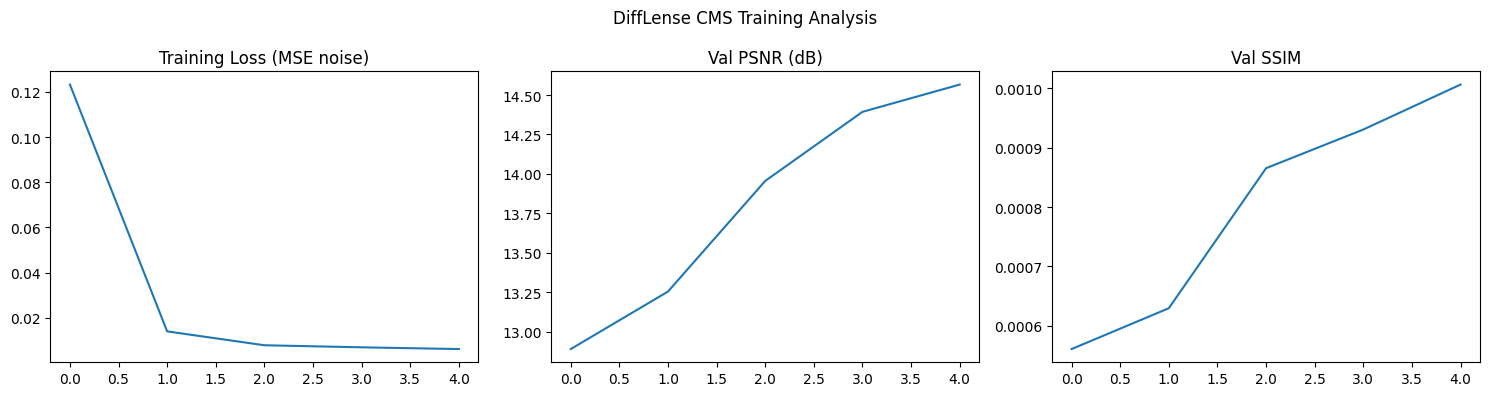

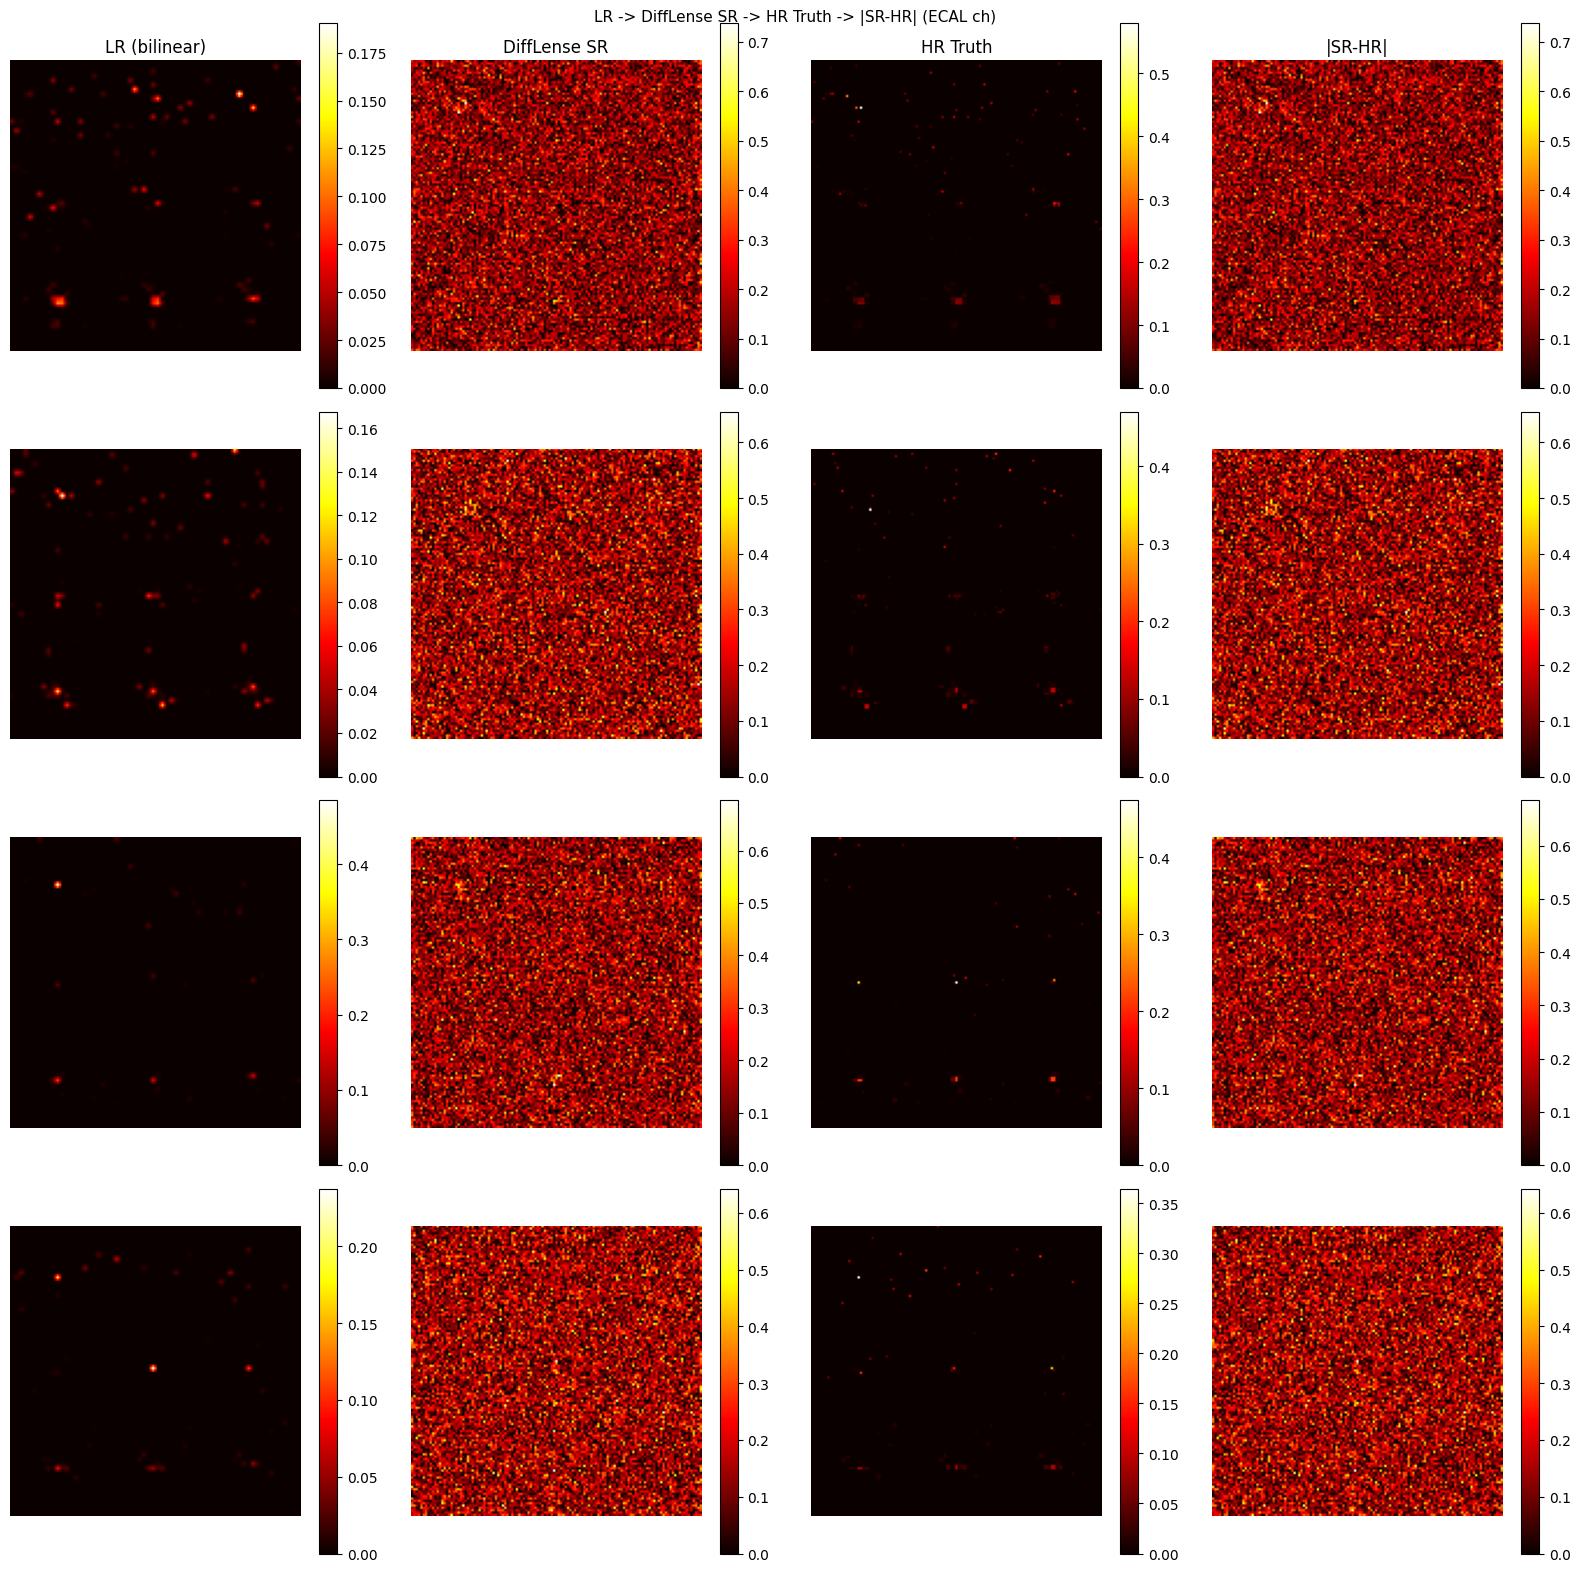

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].plot(hist['loss']); axes[0].set_title('Training Loss (MSE noise)')
axes[1].plot(hist['psnr']); axes[1].set_title('Val PSNR (dB)')
axes[2].plot(hist['ssim']); axes[2].set_title('Val SSIM')
plt.suptitle('DiffLense CMS Training Analysis')
plt.tight_layout(); plt.savefig('difflense_training_curves.png', dpi=100); plt.show()

# Visual comparison
model.eval()
lr_b, hr_b, _ = next(iter(test_loader))
with torch.no_grad():
    sr_b = p_sample_loop(model, lr_b.to(DEVICE), steps=INFER_STEPS).cpu()

fig, axes = plt.subplots(4, 4, figsize=(16,16))
fig.suptitle('LR -> DiffLense SR -> HR Truth -> |SR-HR| (ECAL ch)', fontsize=11)
for row in range(4):
    lr_img = F.interpolate(lr_b[row:row+1], size=(125,125), mode='bilinear').squeeze()[1].numpy()
    sr_img = sr_b[row][1].numpy()
    hr_img = hr_b[row][1].numpy()
    diff   = np.abs(sr_img - hr_img)
    for col, (img, ttl) in enumerate(zip([lr_img, sr_img, hr_img, diff],
                                         ['LR (bilinear)', 'DiffLense SR', 'HR Truth', '|SR-HR|'])):
        im = axes[row, col].imshow(img, cmap='hot')
        axes[row, col].set_title(ttl if row==0 else '')
        axes[row, col].axis('off')
        plt.colorbar(im, ax=axes[row, col])
plt.tight_layout(); plt.savefig('difflense_visual_comparison.png', dpi=100); plt.show()